In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Linear _1 assement.csv")

In [3]:
df.head()

,fish_id,species,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g
0,1,Salmon,80.4,84.2,86.6,33.2,20.1,29.8,2.8,12.1,38281.6
1,2,Perch,21.3,22.1,22.6,7.6,7.1,8.5,3.5,8.7,802.8
2,3,Roach,16.1,16.8,17.5,5.9,4.3,5.5,1.3,10.6,225.9
3,4,Perch,12.2,12.7,13.0,4.4,3.7,5.0,1.3,16.1,155.2
4,5,Perch,32.8,33.6,35.2,13.6,10.2,14.2,4.8,21.8,3154.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fish_id       476 non-null    int64  
 1   species       476 non-null    object 
 2   length1_cm    476 non-null    float64
 3   length2_cm    476 non-null    float64
 4   length3_cm    476 non-null    float64
 5   height_cm     476 non-null    float64
 6   width_cm      476 non-null    float64
 7   girth_cm      476 non-null    float64
 8   age_years     476 non-null    float64
 9   water_temp_c  476 non-null    float64
 10  weight_g      476 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 41.0+ KB


In [5]:
df.shape

(476, 11)

In [6]:
df.dtypes

fish_id           int64
species          object
length1_cm      float64
length2_cm      float64
length3_cm      float64
height_cm       float64
width_cm        float64
girth_cm        float64
age_years       float64
water_temp_c    float64
weight_g        float64
dtype: object

In [7]:
df['species'].value_counts()

species
Roach        75
Salmon       74
Pike         71
Perch        67
Whitefish    67
Bream        61
Smelt        61
Name: count, dtype: int64

In [8]:
df.describe()

,fish_id,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000
mean,238.500000,37.926471,39.464706,40.822269,14.157143,10.096218,14.485294,3.461975,15.020378,6086.735714
std,137.553626,20.010818,20.856469,21.521104,7.476152,5.200173,7.324341,1.573653,4.007118,8055.291401
min,1.000000,7.100000,7.300000,7.600000,1.800000,1.300000,2.100000,0.700000,8.000000,7.000000
25%,119.750000,21.400000,22.175000,23.100000,8.100000,6.100000,8.450000,2.200000,11.700000,716.125000
50%,238.500000,33.850000,35.250000,36.450000,13.600000,9.800000,14.150000,3.100000,14.950000,3231.950000
75%,357.250000,48.950000,51.125000,53.050000,18.725000,13.325000,20.100000,4.600000,18.400000,8056.200000
max,476.000000,89.700000,93.900000,96.400000,36.100000,25.600000,33.300000,7.600000,22.000000,48866.900000


In [9]:
df.isnull().sum()

fish_id         0
species         0
length1_cm      0
length2_cm      0
length3_cm      0
height_cm       0
width_cm        0
girth_cm        0
age_years       0
water_temp_c    0
weight_g        0
dtype: int64

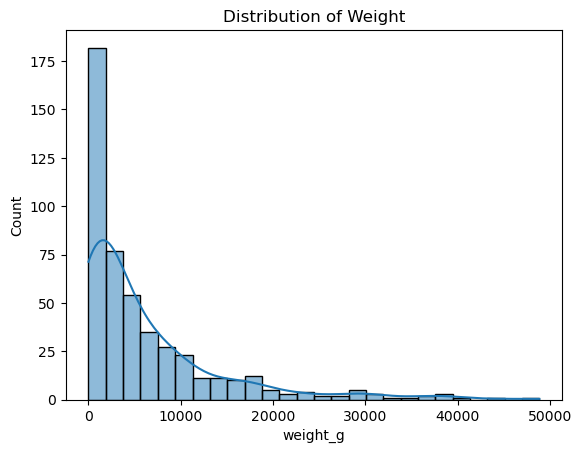

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['weight_g'], kde=True)
plt.title("Distribution of Weight")
plt.show()

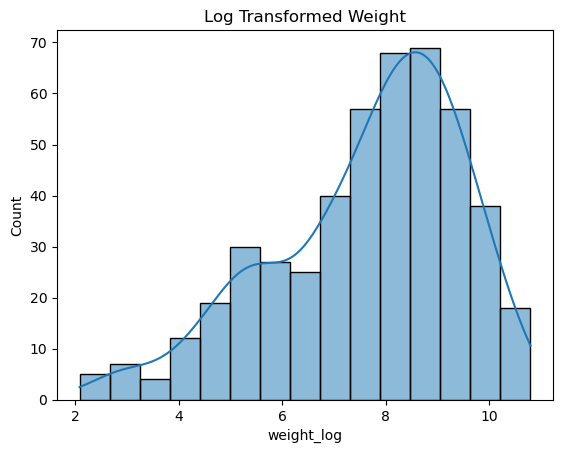

In [11]:
import numpy as np

df['weight_log'] = np.log1p(df['weight_g'])

sns.histplot(df['weight_log'], kde=True)
plt.title("Log Transformed Weight")
plt.show()

In [12]:
corr = df.corr(numeric_only=True)

weight_corr = corr['weight_g'].sort_values(ascending=False)

print(weight_corr)

weight_g        1.000000
height_cm       0.862560
girth_cm        0.853919
width_cm        0.848232
length2_cm      0.835024
length1_cm      0.834787
length3_cm      0.833804
weight_log      0.726086
age_years       0.266010
fish_id         0.029407
water_temp_c   -0.030459
Name: weight_g, dtype: float64


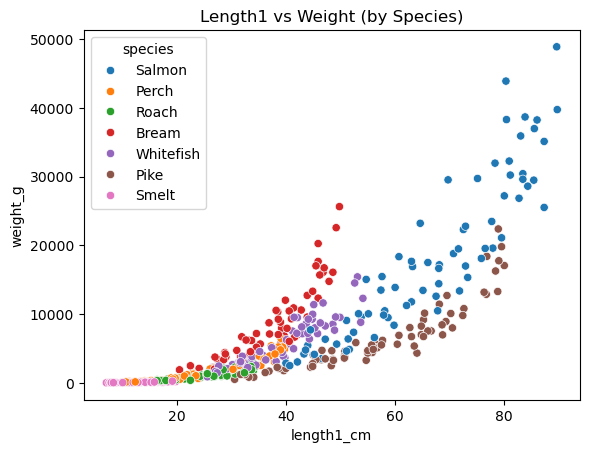

In [13]:
plt.figure()
sns.scatterplot(data=df, x='length1_cm', y='weight_g', hue='species')
plt.title("Length1 vs Weight (by Species)")
plt.show()

In [14]:
df['volume_proxy'] = df['length1_cm']*df['height_cm']*df['width_cm']

In [15]:
df['volume_proxy']

0      53652.528
1       1149.348
2        408.457
3        198.616
4       4550.016
         ...    
471      204.600
472    15860.320
473      468.480
474      627.750
475    63949.600
Name: volume_proxy, Length: 476, dtype: float64

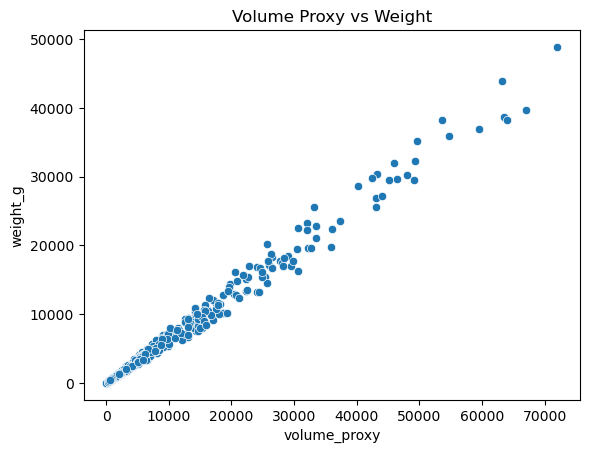

In [16]:
plt.figure()
sns.scatterplot(x=df['volume_proxy'], y=df['weight_g'])
plt.title("Volume Proxy vs Weight")
plt.show()

In [17]:
df['log_weight'] = np.log(df['weight_g'])
df['log_volume'] = np.log(df['volume_proxy'])

# Correlation
print(df[['log_weight', 'log_volume']].corr())

            log_weight  log_volume
log_weight    1.000000    0.998028
log_volume    0.998028    1.000000


In [18]:
df['length_sq'] = df['length1_cm'] ** 2
df['length_cu'] = df['length1_cm'] ** 3

In [19]:
df['length_x_girth'] = df['length1_cm'] * df['girth_cm']

In [20]:
df.drop(['fish_id'],axis=1,inplace=True)

In [21]:
df = pd.get_dummies(df, columns=['species'], drop_first=True)
df

,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g,weight_log,...,log_volume,length_sq,length_cu,length_x_girth,species_Perch,species_Pike,species_Roach,species_Salmon,species_Smelt,species_Whitefish
0,80.4,84.2,86.6,33.2,20.1,29.8,2.8,12.1,38281.6,10.552751,...,10.890284,6464.16,519718.464,2395.92,False,False,False,True,False,False
1,21.3,22.1,22.6,7.6,7.1,8.5,3.5,8.7,802.8,6.689350,...,7.046950,453.69,9663.597,181.05,True,False,False,False,False,False
2,16.1,16.8,17.5,5.9,4.3,5.5,1.3,10.6,225.9,5.424509,...,6.012387,259.21,4173.281,88.55,False,False,True,False,False,False
3,12.2,12.7,13.0,4.4,3.7,5.0,1.3,16.1,155.2,5.051137,...,5.291373,148.84,1815.848,61.00,True,False,False,False,False,False
4,32.8,33.6,35.2,13.6,10.2,14.2,4.8,21.8,3154.2,8.056807,...,8.422886,1075.84,35287.552,465.76,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,12.4,12.9,13.3,5.0,3.3,5.3,1.3,9.6,138.1,4.935193,...,5.321057,153.76,1906.624,65.72,True,False,False,False,False,False
472,68.6,72.0,74.2,17.0,13.6,17.1,5.7,14.5,8432.8,9.040003,...,9.671576,4705.96,322828.856,1173.06,False,True,False,False,False,False
473,19.2,19.6,20.5,6.1,4.0,5.7,7.2,11.8,248.1,5.517854,...,6.149493,368.64,7077.888,109.44,False,False,False,False,True,False
474,22.5,23.8,24.6,6.2,4.5,8.0,3.6,8.1,372.4,5.922650,...,6.442142,506.25,11390.625,180.00,False,False,True,False,False,False


In [22]:
df['condition_factor'] = df['weight_g'] / (df['length1_cm'] ** 3)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# Features: all numeric engineered features
x = df.drop(columns=['weight_g', 'log_weight'])  # exclude target
y = df['weight_g']
y_log = df['log_weight']

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(x, y_log, test_size=0.2, random_state=42)

# Linear regression: weight
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Linear regression: log_weight
model_log = LinearRegression()
model_log.fit(x_train_log, y_train_log)
y_pred_log = np.expm1(model_log.predict(x_test_log))  # back-transform

In [24]:
# Compute metrics
def eval_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

rmse1, mae1, r2_1 = eval_metrics(y_test, y_pred)
rmse2, mae2, r2_2 = eval_metrics(y_test, y_pred_log)

print("Linear vs Log-weight Model")
print(f"Linear RMSE: {rmse1:.2f}, MAE: {mae1:.2f}, R2: {r2_1:.3f}")
print(f"Log RMSE: {rmse2:.2f}, MAE: {mae2:.2f}, R2: {r2_2:.3f}")

Linear vs Log-weight Model
Linear RMSE: 627.50, MAE: 377.19, R2: 0.994
Log RMSE: 62.60, MAE: 23.61, R2: 1.000


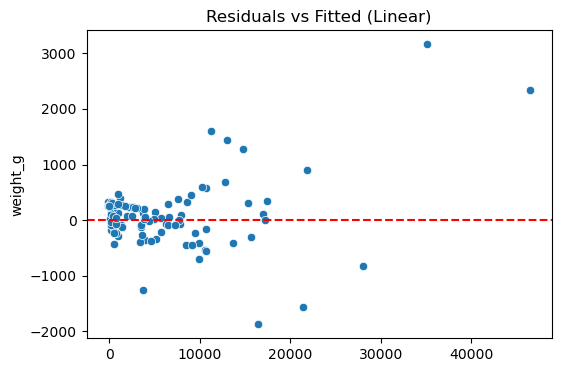

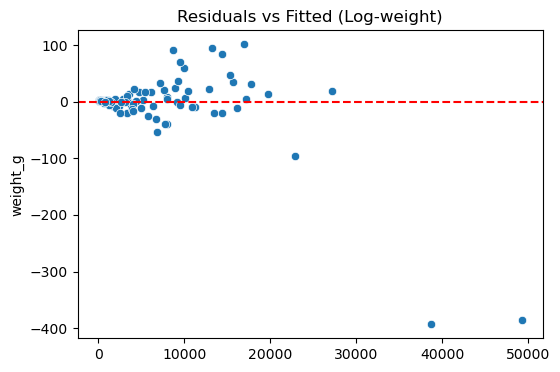

In [25]:
# Residual plots
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=y_test - y_pred)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Linear)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_log, y=y_test - y_pred_log)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Log-weight)")
plt.show()

In [26]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']